# Mapping Market States with a Variational Autoencoder

Financial markets are often described using simple labels: *trend*, *stress*, *mean reversion*, or *macro-driven rotation*. The difficulty is that these labels are not directly observable. They are interpretations of many interacting variables: price returns, volatility, range expansion, macro context, the dollar, commodities, bonds, and risk sentiment.

This notebook explores whether a simple **Variational Autoencoder (VAE)** can compress rolling S&P 500 market windows into a two-dimensional latent space that remains economically interpretable.

The goal is **not** to build a trading signal or directly forecast prices. The goal is narrower and more useful:

> Can a probabilistic representation model organize recent market behaviour into latent coordinates that resemble trend strength, volatility stress, mean-reversion pressure, and macro-commodity context?

The analysis uses `SPY` as the S&P 500 proxy and adds context from volatility, commodities, the dollar, crude oil, bonds, and gold. The final outputs are latent-space charts, regime summaries, anomaly windows, and a cautious interpretation of what the model appears to learn.

## Executive summary

This notebook trains a small two-dimensional VAE on rolling S&P 500 market windows.

The executed results suggest:

- The model reduced training loss by approximately **45.1%** over 40 epochs.
- `z2` is most strongly associated with **trend strength** with correlation **0.662**.
- `z1` is most strongly associated with **macro commodity context** with correlation **0.458**.
- Reconstruction error highlights unusual market windows and is modestly associated with volatility stress.
- A small high-stress regime is concentrated around **March–May 2020**, which is consistent with the COVID crash/rebound window.
- The model is best interpreted as a **market-state representation layer**, not as a standalone forecasting or trading model.

## 1. Conceptual intuition

A Variational Autoencoder has three pieces:

1. **Encoder** — compresses a high-dimensional market window into a small latent distribution.
2. **Latent space** — stores the compressed state as a probabilistic coordinate.
3. **Decoder** — tries to reconstruct the original market window from that coordinate.

In this notebook, one input sample is not a single price point. It is a rolling market window containing recent values of trend, volatility, mean-reversion, and macro-context features. The VAE learns whether these windows can be summarized with only two latent variables.

Mathematically, the encoder estimates a latent mean and variance:

$$
q_\phi(z \mid x) = \mathcal{N}(\mu(x), \sigma^2(x))
$$

The model samples a latent vector using the reparameterization trick:

$$
z = \mu + \sigma \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)
$$

The decoder then attempts to reconstruct the original market window:

$$
\hat{x} = p_\theta(x \mid z)
$$

The training objective combines reconstruction quality with latent-space regularization:

$$
\mathcal{L} = \text{MSE}(x, \hat{x}) + \beta \cdot D_{KL}\left(q_\phi(z \mid x) \| \mathcal{N}(0, I)\right)
$$

Because financial time series are noisy, this notebook uses a small KL weight, `beta = 0.001`. This makes the model behave like a lightly regularized probabilistic autoencoder: it prioritizes reconstructing market states while still encouraging a smoother latent representation.

This choice is deliberate, but it also limits the strength of any generative claims. The model should be read primarily as a **representation-learning tool**, not as a standalone market simulator.

## 2. Overall approach

The workflow is:

```text
Daily market and macro-context prices
        ↓
Feature engineering
        ↓
Rolling 20-day market windows
        ↓
Standardization using the training sample
        ↓
Two-dimensional VAE
        ↓
Latent-space interpretation
        ↓
Regime summaries and anomaly detection
```

The four interpretive concepts used throughout the notebook are:

| Concept | What it tries to capture | Example ingredients |
|---|---|---|
| Trend strength | Whether the S&P 500 is moving persistently in one direction | 20-day return, 60-day return, moving-average gap, moving-average slope |
| Volatility stress | Whether the market is unusually turbulent | realized volatility, intraday range shock, VIX z-score |
| Mean-reversion pressure | Whether price looks stretched relative to recent history | Bollinger z-score, RSI, distance from moving average |
| Macro commodity context | Whether commodities/oil/dollar conditions are influential | DBC, USO, UUP returns |

The VAE is then evaluated by checking whether its latent dimensions correlate with these interpretable concepts.

## 3. Setup

This notebook uses daily market data, standard Python data-science libraries, and a compact PyTorch VAE.

Install dependencies if needed:

```bash
pip install yfinance torch scikit-learn pandas numpy matplotlib
```

The notebook includes a synthetic-data fallback so the code structure remains executable if external download fails. The results shown here are based on real downloaded data from the executed run.

In [3]:
import warnings
warnings.filterwarnings("ignore")

from dataclasses import dataclass
from typing import List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

try:
    import yfinance as yf
    YFINANCE_AVAILABLE = True
except Exception:
    YFINANCE_AVAILABLE = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)
print("yfinance available:", YFINANCE_AVAILABLE)

Using device: mps
yfinance available: True


## 4. Configuration

`SPY` is used as a tradable proxy for the S&P 500. The model also receives context from assets that are often useful for interpreting broad market states:

- `^VIX`: volatility-stress proxy
- `DBC`: broad commodity proxy
- `UUP`: US dollar proxy
- `USO`: crude oil proxy
- `TLT`: long-duration bond proxy
- `GLD`: gold proxy

The VAE is trained on **rolling windows of engineered features**, not on raw prices alone. The default setting uses 20 trading days and a two-dimensional latent space so the output can be visualized and explained.

In [4]:
@dataclass
class Config:
    market_ticker: str = "SPY"
    context_tickers: Tuple[str, ...] = ("^VIX", "DBC", "UUP", "USO", "TLT", "GLD")
    start_date: str = "2010-01-01"
    end_date: str | None = None
    window_size: int = 20
    horizon_days: int = 5
    latent_dim: int = 2
    batch_size: int = 128
    epochs: int = 40
    learning_rate: float = 1e-3
    beta_kl: float = 0.001
    train_fraction: float = 0.75
    use_synthetic_if_download_fails: bool = True

cfg = Config()
cfg

Config(market_ticker='SPY', context_tickers=('^VIX', 'DBC', 'UUP', 'USO', 'TLT', 'GLD'), start_date='2010-01-01', end_date=None, window_size=20, horizon_days=5, latent_dim=2, batch_size=128, epochs=40, learning_rate=0.001, beta_kl=0.001, train_fraction=0.75, use_synthetic_if_download_fails=True)

## 5. Data loading

The data loader returns a long-format dataframe with:

```text
date, open, high, low, close, volume, ticker
```

The long format makes it easier to compute ticker-level features and later pivot the context variables into a single market-state table.

### Result from this run

The executed notebook downloaded **29,114 daily rows** across seven tickers:

```text
DBC, GLD, SPY, TLT, USO, UUP, ^VIX
```

This gives a broad market sample from 2010 through the latest available observations in the executed run.

In [5]:
def download_market_data(cfg: Config) -> pd.DataFrame:
    """Download OHLCV data and return a clean long dataframe.

    yfinance can return MultiIndex columns in two different layouts depending on
    version and parameters:
      1. first level = ticker, second level = OHLCV field
      2. first level = OHLCV field, second level = ticker

    This function handles both, and always returns columns:
      date, open, high, low, close, volume, ticker
    """
    if not YFINANCE_AVAILABLE:
        raise RuntimeError("yfinance is not available")

    tickers = [cfg.market_ticker] + list(cfg.context_tickers)
    raw = yf.download(
        tickers,
        start=cfg.start_date,
        end=cfg.end_date,
        auto_adjust=True,
        progress=False,
        group_by="ticker",
        threads=True,
    )

    if raw.empty:
        raise RuntimeError("No data downloaded")

    def clean_cols(df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        df.columns = [str(c).lower().replace(" ", "_") for c in df.columns]
        df = df.reset_index().rename(columns={"Date": "date", "Datetime": "date", "index": "date"})
        df["date"] = pd.to_datetime(df["date"]).dt.tz_localize(None)
        return df

    frames = []

    if isinstance(raw.columns, pd.MultiIndex):
        level0 = set(raw.columns.get_level_values(0))
        level1 = set(raw.columns.get_level_values(1))

        for ticker in tickers:
            temp = None

            # Layout A: columns like ('SPY', 'Close')
            if ticker in level0:
                temp = raw[ticker].copy()

            # Layout B: columns like ('Close', 'SPY')
            elif ticker in level1:
                temp = raw.xs(ticker, axis=1, level=1).copy()

            if temp is None or temp.empty:
                print(f"Warning: no data found for {ticker}")
                continue

            temp = clean_cols(temp)
            temp["ticker"] = ticker
            frames.append(temp)

    else:
        # Single ticker fallback.
        temp = clean_cols(raw)
        temp["ticker"] = tickers[0]
        frames.append(temp)

    if not frames:
        raise RuntimeError("No ticker frames were created from yfinance output")

    out = pd.concat(frames, ignore_index=True)

    # Ensure the required fields exist. Some index-like series may not include volume.
    for col in ["open", "high", "low", "close"]:
        if col not in out.columns:
            raise ValueError(f"Required column missing after download: {col}. Columns: {out.columns.tolist()}")
    if "volume" not in out.columns:
        out["volume"] = np.nan

    keep = ["date", "open", "high", "low", "close", "volume", "ticker"]
    out = out[keep].dropna(subset=["date", "open", "high", "low", "close", "ticker"])
    out = out.sort_values(["ticker", "date"]).reset_index(drop=True)
    return out


def make_synthetic_market_data(cfg: Config, n_days: int = 2600) -> pd.DataFrame:
    """Synthetic fallback: creates regime-like OHLCV for SPY and context tickers."""
    tickers = [cfg.market_ticker] + list(cfg.context_tickers)
    dates = pd.bdate_range(cfg.start_date, periods=n_days)
    rng = np.random.default_rng(RANDOM_STATE)

    regimes = rng.choice([0, 1, 2, 3], size=n_days, p=[0.45, 0.25, 0.20, 0.10])

    rows = []
    for ticker in tickers:
        price = 100.0
        for i, d in enumerate(dates):
            r = regimes[i]
            base_mu = 0.0002
            vol = 0.008

            if ticker == cfg.market_ticker:
                if r == 1:
                    mu, vol = 0.0009, 0.010
                elif r == 2:
                    mu, vol = -0.0008, 0.022
                elif r == 3:
                    mu, vol = 0.0001, 0.014
                else:
                    mu, vol = base_mu, vol
            elif ticker == "^VIX":
                mu, vol = (0.002 if r == 2 else -0.0002), 0.030
            elif ticker == "DBC":
                mu, vol = (0.0012 if r == 3 else 0.0001), 0.012
            elif ticker == "UUP":
                mu, vol = (0.0008 if r == 2 else -0.0001), 0.006
            elif ticker == "USO":
                mu, vol = (0.0015 if r == 3 else 0.0001), 0.020
            elif ticker == "TLT":
                mu, vol = (0.0008 if r == 2 else -0.0001), 0.009
            elif ticker == "GLD":
                mu, vol = (0.0007 if r in [2, 3] else 0.0001), 0.010
            else:
                mu, vol = base_mu, vol

            ret = rng.normal(mu, vol)
            open_p = price * (1 + rng.normal(0, vol / 4))
            close_p = max(1.0, open_p * (1 + ret))
            hi = max(open_p, close_p) * (1 + abs(rng.normal(0, vol / 2)))
            lo = min(open_p, close_p) * (1 - abs(rng.normal(0, vol / 2)))
            volume = int(abs(rng.normal(2_000_000, 500_000)) * (1.5 if r == 2 else 1.0))
            price = close_p
            rows.append([d, open_p, hi, lo, close_p, volume, ticker])

    return pd.DataFrame(rows, columns=["date", "open", "high", "low", "close", "volume", "ticker"])


try:
    prices = download_market_data(cfg)
    print("Downloaded real data:", prices.shape)
except Exception as e:
    print("Download failed:", repr(e))
    if cfg.use_synthetic_if_download_fails:
        prices = make_synthetic_market_data(cfg)
        print("Using synthetic fallback:", prices.shape)
    else:
        raise

print("Columns:", prices.columns.tolist())
print("Tickers:", sorted(prices["ticker"].unique()))
prices.head()


Downloaded real data: (29114, 7)
Columns: ['date', 'open', 'high', 'low', 'close', 'volume', 'ticker']
Tickers: ['DBC', 'GLD', 'SPY', 'TLT', 'USO', 'UUP', '^VIX']


,date,open,high,low,close,volume,ticker
0,2010-01-04,21.279666,21.338846,21.195122,21.338846,2046900.0,DBC
1,2010-01-05,21.364210,21.414936,21.237395,21.364210,2335400.0,DBC
2,2010-01-06,21.474114,21.753108,21.389570,21.744654,2262600.0,DBC
3,2010-01-07,21.668566,21.685475,21.474115,21.474115,1604100.0,DBC
4,2010-01-08,21.423390,21.541751,21.330391,21.457207,1565300.0,DBC


### What the data table shows

The first rows confirm that the loader produced the intended long-format dataset. Each ticker has its own daily OHLCV history, which later allows the notebook to compute ticker-specific returns, volatility, range shock, and context features before merging everything into one market-state table.

This is important because the VAE is not trained on a single price series alone. It is trained on a market window enriched with volatility, commodity, dollar, oil, bond, and gold context.

## 6. Feature engineering

The raw prices are converted into features that are easier to interpret economically.

### Trend strength
Examples: 20-day return, 60-day return, moving-average slope, distance from moving average.

### Volatility stress
Examples: realized volatility, daily range percentage, range shock, VIX level, and VIX z-score.

### Mean-reversion pressure
Examples: Bollinger z-score, RSI, distance from recent moving average.

### Macro commodity regime
Examples: broad commodity momentum, crude-oil momentum, and dollar strength.

These engineered features are not perfect definitions of the concepts. They are practical proxies that allow the latent space to be interpreted after the model is trained.

In [6]:

def rsi(series: pd.Series, window: int = 14) -> pd.Series:
    delta = series.diff()
    gain = delta.clip(lower=0).rolling(window).mean()
    loss = (-delta.clip(upper=0)).rolling(window).mean()
    rs = gain / loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


def add_single_ticker_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add single-ticker market-state features.

    Important: this function does not rely on pandas groupby.apply.
    The outer loop explicitly adds ticker back after feature generation.
    """
    df = df.sort_values("date").copy()
    c = df["close"]
    h = df["high"]
    l = df["low"]
    v = df["volume"]

    df["ret_1d"] = c.pct_change()
    df["ret_5d"] = c.pct_change(5)
    df["ret_20d"] = c.pct_change(20)
    df["ret_60d"] = c.pct_change(60)

    df["ma_20"] = c.rolling(20).mean()
    df["ma_60"] = c.rolling(60).mean()
    df["ma_gap_20"] = c / df["ma_20"] - 1
    df["ma_gap_60"] = c / df["ma_60"] - 1
    df["ma_slope_20"] = df["ma_20"].pct_change(5)

    df["realized_vol_20"] = df["ret_1d"].rolling(20).std() * np.sqrt(252)
    df["range_pct"] = (h - l) / c.shift(1)
    df["range_shock_20"] = df["range_pct"] / df["range_pct"].rolling(20).median()

    df["bollinger_z_20"] = (c - df["ma_20"]) / c.rolling(20).std()
    df["rsi_14"] = rsi(c, 14)
    df["volume_z_20"] = (v - v.rolling(20).mean()) / v.rolling(20).std()

    df["forward_ret_5d"] = c.shift(-5) / c - 1
    return df


required_price_cols = {"date", "ticker", "open", "high", "low", "close"}
missing_price_cols = required_price_cols - set(prices.columns)
if missing_price_cols:
    raise ValueError(f"prices is missing required columns: {missing_price_cols}. Available: {prices.columns.tolist()}")

# Make sure date and ticker are plain columns, not index levels.
prices = prices.copy().reset_index(drop=True)
prices["date"] = pd.to_datetime(prices["date"]).dt.tz_localize(None)
prices["ticker"] = prices["ticker"].astype(str)

# Avoid pandas groupby.apply behavior changes by building frames explicitly.
feature_frames = []
for ticker, g in prices.groupby("ticker", sort=False):
    temp = add_single_ticker_features(g.copy())
    temp["ticker"] = ticker  # preserve ticker explicitly
    feature_frames.append(temp.reset_index(drop=True))

feature_df = pd.concat(feature_frames, ignore_index=True)
feature_df = feature_df.sort_values(["ticker", "date"]).reset_index(drop=True)

print("Feature dataframe shape:", feature_df.shape)
print("Feature columns include ticker:", "ticker" in feature_df.columns)
print("Tickers:", sorted(feature_df["ticker"].unique()))
feature_df[["date", "ticker", "close", "ret_20d", "realized_vol_20", "bollinger_z_20"]].tail()


Feature dataframe shape: (29114, 23)
Feature columns include ticker: True
Tickers: ['DBC', 'GLD', 'SPY', 'TLT', 'USO', 'UUP', '^VIX']


,date,ticker,close,ret_20d,realized_vol_20,bollinger_z_20
29109,2026-07-13,^VIX,17.16,-0.117284,1.170289,0.078292
29110,2026-07-14,^VIX,16.50,-0.066742,1.133043,-0.417970
29111,2026-07-15,^VIX,15.67,-0.032716,1.106631,-1.060543
29112,2026-07-16,^VIX,16.73,0.019500,1.131490,-0.216023
29113,2026-07-17,^VIX,18.77,0.017896,1.129009,1.404759


### What the feature table shows

The feature-engineering step successfully preserved the `ticker` column and produced **29,114 rows** with ticker-level features.

The displayed rows are from `^VIX`, which naturally has very different behaviour from `SPY`. That is intentional: the context series provides information about stress and macro conditions, while `SPY` remains the main equity-market object being represented.

In [7]:

def make_wide_context(feature_df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    """Convert long ticker-level features into one market-level dataframe.

    The VAE in this notebook models SPY market windows, while context tickers
    provide macro/commodity/dollar/oil information.
    """
    df = feature_df.copy()

    # Ensure date and ticker are available as explicit columns.
    for needed in ["date", "ticker"]:
        if needed not in df.columns and needed in getattr(df.index, "names", []):
            df = df.reset_index()

    if "ticker" not in df.columns:
        raise KeyError(
            "feature_df has no 'ticker' column. The prices dataframe is fine, but the feature-building cell likely used old groupby.apply code. "
            "Restart the kernel and rerun the explicit feature_frames loop. "
            f"Available columns: {df.columns.tolist()}"
        )
    if "date" not in df.columns:
        raise KeyError(f"feature_df has no 'date' column. Available columns: {df.columns.tolist()}")

    df["date"] = pd.to_datetime(df["date"]).dt.tz_localize(None)
    df["ticker"] = df["ticker"].astype(str)

    # pivot_table is safer than pivot if duplicate rows exist for the same date/ticker.
    wide_close = df.pivot_table(index="date", columns="ticker", values="close", aggfunc="last").sort_index()

    if cfg.market_ticker not in wide_close.columns:
        raise KeyError(
            f"Market ticker {cfg.market_ticker} not found in close matrix. "
            f"Available tickers: {wide_close.columns.tolist()}"
        )

    market = (
        df[df["ticker"] == cfg.market_ticker]
        .sort_values("date")
        .drop_duplicates(subset=["date"], keep="last")
        .set_index("date")
    )

    out = pd.DataFrame(index=wide_close.index)
    out["close"] = wide_close[cfg.market_ticker]
    out["forward_ret_5d"] = market["forward_ret_5d"]

    out["trend_ret_20"] = market["ret_20d"]
    out["trend_ret_60"] = market["ret_60d"]
    out["trend_ma_gap_20"] = market["ma_gap_20"]
    out["trend_ma_slope_20"] = market["ma_slope_20"]

    out["vol_realized_20"] = market["realized_vol_20"]
    out["vol_range_shock_20"] = market["range_shock_20"]
    out["vol_range_pct"] = market["range_pct"]

    out["mr_bollinger_z_20"] = market["bollinger_z_20"]
    out["mr_rsi_14"] = market["rsi_14"]
    out["mr_ma_gap_20"] = market["ma_gap_20"]

    for ticker in cfg.context_tickers:
        if ticker in wide_close.columns:
            clean_name = ticker.replace("^", "")
            out[f"ctx_{clean_name}_ret_5d"] = wide_close[ticker].pct_change(5)
            out[f"ctx_{clean_name}_ret_20d"] = wide_close[ticker].pct_change(20)

    if "^VIX" in wide_close.columns:
        vix = wide_close["^VIX"]
        out["vix_level"] = vix
        out["vix_z_60"] = (vix - vix.rolling(60).mean()) / vix.rolling(60).std()
    else:
        out["vix_level"] = np.nan
        out["vix_z_60"] = 0.0

    out["commodity_regime_20"] = wide_close["DBC"].pct_change(20) if "DBC" in wide_close.columns else 0.0
    out["dollar_regime_20"] = wide_close["UUP"].pct_change(20) if "UUP" in wide_close.columns else 0.0
    out["oil_regime_20"] = wide_close["USO"].pct_change(20) if "USO" in wide_close.columns else 0.0

    # Four article-friendly interpretable labels.
    out["trend_strength"] = out[["trend_ret_20", "trend_ma_gap_20", "trend_ma_slope_20"]].mean(axis=1)
    out["volatility_stress"] = out[["vol_realized_20", "vol_range_shock_20", "vix_z_60"]].mean(axis=1)
    out["mean_reversion_pressure"] = out[["mr_bollinger_z_20", "mr_ma_gap_20"]].mean(axis=1)
    out["macro_commodity_regime"] = out[["commodity_regime_20", "oil_regime_20"]].mean(axis=1) - out["dollar_regime_20"].fillna(0)

    return out.reset_index().rename(columns={"index": "date"}).dropna().sort_values("date")


market_state = make_wide_context(feature_df, cfg)
print(market_state.shape)
market_state.tail()


(4092, 34)


,date,close,forward_ret_5d,trend_ret_20,trend_ret_60,trend_ma_gap_20,trend_ma_slope_20,vol_realized_20,vol_range_shock_20,vol_range_pct,...,ctx_GLD_ret_20d,vix_level,vix_z_60,commodity_regime_20,dollar_regime_20,oil_regime_20,trend_strength,volatility_stress,mean_reversion_pressure,macro_commodity_regime
4150,2026-07-06,751.280029,-0.002809,-0.005118,0.114208,0.015340,-0.003139,0.183671,0.533374,0.006713,...,-0.070854,15.570000,-1.552421,-0.096386,0.017241,-0.236873,0.002361,-0.278459,0.750299,-0.183871
4151,2026-07-07,747.710022,0.005510,0.016387,0.102552,0.009693,-0.001417,0.158156,0.687484,0.007654,...,-0.047320,16.129999,-1.114443,-0.064317,0.013562,-0.181176,0.008221,-0.089601,0.467235,-0.136308
4152,2026-07-08,745.400024,0.012624,0.010958,0.099874,0.006025,-0.000210,0.158667,0.797687,0.008880,...,-0.057442,16.900000,-0.542177,-0.056668,0.011773,-0.169737,0.005591,0.138059,0.289312,-0.124976
4153,2026-07-09,751.710022,-0.001317,0.022518,0.098450,0.013409,0.001708,0.160455,0.879246,0.008559,...,-0.032243,15.840000,-1.258501,-0.051256,0.012496,-0.169764,0.012545,-0.072933,0.626370,-0.123005
4154,2026-07-10,754.950012,-0.015445,0.043374,0.089904,0.015628,0.004338,0.147680,1.005975,0.009738,...,0.006487,15.030000,-1.750579,-0.056565,0.012121,-0.190618,0.021113,-0.198975,0.801646,-0.135713


### Result: market-state dataframe

The market-state dataframe contains **4,092 daily observations** and **34 columns** after aligning all tickers and removing rows with missing rolling features.

This table is the core modeling dataset. Each row represents one date, with `SPY` features plus macro-context variables from `^VIX`, `DBC`, `UUP`, `USO`, `TLT`, and `GLD`.

The last rows show July 2026 observations. The negative `macro_commodity_regime` values near the end of the sample indicate that commodity/oil context was not strongly supportive relative to the dollar component in those windows.

## 7. Build rolling windows for the VAE

The VAE input is a flattened rolling market window:

```text
window_size × number_of_features
```

In this run, the model uses:

```text
20 trading days × 31 features = 620 input values
```

Each sample therefore represents a compact snapshot of the previous 20 trading days of market behaviour. The target is not a label; the VAE simply learns to reconstruct these market windows through a low-dimensional bottleneck.

In [8]:
INTERPRETATION_COLS = [
    "trend_strength",
    "volatility_stress",
    "mean_reversion_pressure",
    "macro_commodity_regime",
]

EXCLUDE_COLS = ["date", "close", "forward_ret_5d"]
FEATURE_COLS = [c for c in market_state.columns if c not in EXCLUDE_COLS]

print("Number of features:", len(FEATURE_COLS))
print(FEATURE_COLS)

Number of features: 31
['trend_ret_20', 'trend_ret_60', 'trend_ma_gap_20', 'trend_ma_slope_20', 'vol_realized_20', 'vol_range_shock_20', 'vol_range_pct', 'mr_bollinger_z_20', 'mr_rsi_14', 'mr_ma_gap_20', 'ctx_VIX_ret_5d', 'ctx_VIX_ret_20d', 'ctx_DBC_ret_5d', 'ctx_DBC_ret_20d', 'ctx_UUP_ret_5d', 'ctx_UUP_ret_20d', 'ctx_USO_ret_5d', 'ctx_USO_ret_20d', 'ctx_TLT_ret_5d', 'ctx_TLT_ret_20d', 'ctx_GLD_ret_5d', 'ctx_GLD_ret_20d', 'vix_level', 'vix_z_60', 'commodity_regime_20', 'dollar_regime_20', 'oil_regime_20', 'trend_strength', 'volatility_stress', 'mean_reversion_pressure', 'macro_commodity_regime']


### Result: selected feature set

The notebook uses **31 features**. These include raw components such as returns, volatility, VIX, and context-asset returns, plus four article-friendly interpretation variables:

```text
trend_strength
volatility_stress
mean_reversion_pressure
macro_commodity_regime
```

These four variables are not separate model targets. They are used after training to interpret what the VAE latent space appears to represent.

In [9]:
def make_vae_windows(df: pd.DataFrame, feature_cols: List[str], window_size: int):
    df = df.sort_values("date").reset_index(drop=True).copy()
    X = df[feature_cols].values.astype("float32")
    dates = []
    windows = []
    rows = []

    for end_idx in range(window_size - 1, len(df)):
        start_idx = end_idx - window_size + 1
        window = X[start_idx:end_idx + 1]
        windows.append(window.reshape(-1))
        dates.append(df.loc[end_idx, "date"])
        rows.append(df.loc[end_idx].copy())

    window_df = pd.DataFrame(rows).reset_index(drop=True)
    window_df["window_end_date"] = dates
    return np.array(windows, dtype="float32"), window_df


X_raw, window_meta = make_vae_windows(market_state, FEATURE_COLS, cfg.window_size)
print("Raw window matrix:", X_raw.shape)
window_meta[["date", "trend_strength", "volatility_stress", "mean_reversion_pressure", "macro_commodity_regime"]].tail()

Raw window matrix: (4073, 620)


,date,trend_strength,volatility_stress,mean_reversion_pressure,macro_commodity_regime
4068,2026-07-06,0.002361,-0.278459,0.750299,-0.183871
4069,2026-07-07,0.008221,-0.089601,0.467235,-0.136308
4070,2026-07-08,0.005591,0.138059,0.289312,-0.124976
4071,2026-07-09,0.012545,-0.072933,0.626370,-0.123005
4072,2026-07-10,0.021113,-0.198975,0.801646,-0.135713


### Result: rolling windows

The window matrix has **4,073 samples** and **620 input values** per sample.

That number comes from:

```text
20 days × 31 features = 620 inputs
```

Each sample is therefore a short market-history panel. The VAE must compress this 620-dimensional window into only two latent coordinates and then reconstruct it.

In [10]:
n = len(X_raw)
train_n = int(n * cfg.train_fraction)

X_train_raw = X_raw[:train_n]
X_test_raw = X_raw[train_n:]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw).astype("float32")
X_test = scaler.transform(X_test_raw).astype("float32")
X_all = scaler.transform(X_raw).astype("float32")

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train)),
    batch_size=cfg.batch_size,
    shuffle=True,
)

test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test)),
    batch_size=cfg.batch_size,
    shuffle=False,
)

input_dim = X_train.shape[1]
print("Input dimension:", input_dim)
print("Train windows:", len(X_train), "Test windows:", len(X_test))

Input dimension: 620
Train windows: 3054 Test windows: 1019


### Result: train/test split

The standardized modeling matrix was split chronologically:

- **3,054 windows** for training
- **1,019 windows** for testing / later-period representation

The scaler is fit only on the training windows and then applied to the full sample. This avoids using future information to standardize the training data.

## 8. PyTorch VAE for market windows

Because the input features are standardized continuous variables, the model uses mean squared reconstruction loss.

The loss has two parts:

- **Reconstruction loss:** how well the decoder rebuilds the original market window.
- **KL penalty:** how strongly the latent representation is regularized toward a smooth standard normal distribution.

The KL term is intentionally small in this first experiment. That makes the latent coordinates more stable for interpretation, but it also means we should not overstate the model as a fully generative market simulator.

In [11]:
class FinanceVAE(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 128, latent_dim: int = 2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(hidden_dim // 2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim // 2, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstructed = self.decode(z)
        return reconstructed, mu, logvar


def vae_loss(reconstructed, x, mu, logvar, beta_kl: float = 0.001):
    recon = F.mse_loss(reconstructed, x, reduction="sum")
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + beta_kl * kl, recon, kl


model = FinanceVAE(input_dim=input_dim, hidden_dim=128, latent_dim=cfg.latent_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.learning_rate)
model

FinanceVAE(
  (encoder): Sequential(
    (0): Linear(in_features=620, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
  )
  (fc_mu): Linear(in_features=64, out_features=2, bias=True)
  (fc_logvar): Linear(in_features=64, out_features=2, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=620, bias=True)
  )
)

In [12]:
def train_vae(model, train_loader, epochs: int, beta_kl: float):
    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = total_recon = total_kl = 0.0
        n_obs = 0

        for (x,) in train_loader:
            x = x.to(device)
            optimizer.zero_grad()
            reconstructed, mu, logvar = model(x)
            loss, recon, kl = vae_loss(reconstructed, x, mu, logvar, beta_kl=beta_kl)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_recon += recon.item()
            total_kl += kl.item()
            n_obs += x.shape[0]

        history.append({
            "epoch": epoch,
            "loss": total_loss / n_obs,
            "reconstruction": total_recon / n_obs,
            "kl": total_kl / n_obs,
        })
        if epoch == 1 or epoch % 5 == 0:
            print(
                f"Epoch {epoch:03d} | "
                f"Loss {total_loss / n_obs:.4f} | "
                f"Recon {total_recon / n_obs:.4f} | "
                f"KL {total_kl / n_obs:.4f}"
            )
    return pd.DataFrame(history)


history = train_vae(model, train_loader, cfg.epochs, cfg.beta_kl)

Epoch 001 | Loss 558.9243 | Recon 558.9128 | KL 11.4521
Epoch 005 | Loss 390.6305 | Recon 390.6032 | KL 27.3112
Epoch 010 | Loss 354.0066 | Recon 353.9700 | KL 36.5918
Epoch 015 | Loss 337.7927 | Recon 337.7501 | KL 42.4999
Epoch 020 | Loss 328.9178 | Recon 328.8701 | KL 47.6982
Epoch 025 | Loss 320.7469 | Recon 320.6944 | KL 52.5776
Epoch 030 | Loss 313.3004 | Recon 313.2438 | KL 56.6742
Epoch 035 | Loss 307.9583 | Recon 307.8991 | KL 59.1823
Epoch 040 | Loss 306.6692 | Recon 306.6076 | KL 61.5706


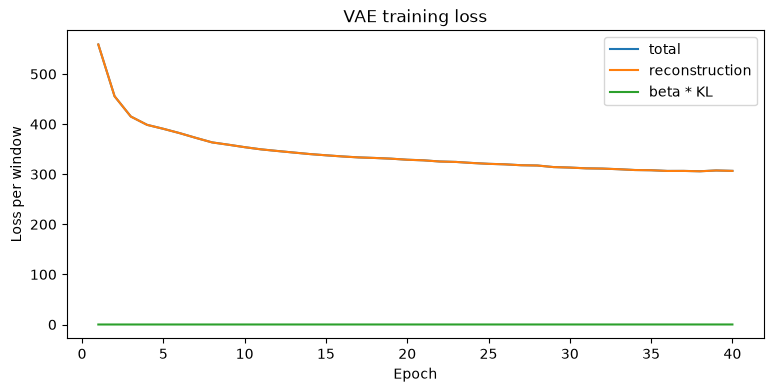

In [13]:
plt.figure(figsize=(9, 4))
plt.plot(history["epoch"], history["loss"], label="total")
plt.plot(history["epoch"], history["reconstruction"], label="reconstruction")
plt.plot(history["epoch"], history["kl"] * cfg.beta_kl, label="beta * KL")
plt.title("VAE training loss")
plt.xlabel("Epoch")
plt.ylabel("Loss per window")
plt.legend()
plt.show()

### Result: training curve

The training curve shows that the VAE learned a substantially better reconstruction of the rolling market windows.

In this executed run:

- Loss declined from **558.92** to **306.67** per window.
- That is an approximate **45.1% reduction** over 40 epochs.
- The final unweighted KL value was **61.57**, but because `beta = 0.001`, the weighted KL contribution was only about **0.062**.

This confirms that the model mainly learned a compact reconstruction of market states. The latent space is lightly regularized, but the reconstruction objective dominates.

## 9. Encode market windows into latent space

After training, each rolling market window is passed through the encoder. The encoder returns:

- `z1`: first latent coordinate
- `z2`: second latent coordinate
- `z1_uncertainty`, `z2_uncertainty`: estimated latent variances
- `reconstruction_error`: how difficult the window was to reconstruct

The interpretation comes from comparing these latent outputs with the original market-state concepts.

In [14]:
def encode_windows(model, X: np.ndarray) -> pd.DataFrame:
    model.eval()
    x = torch.tensor(X, dtype=torch.float32).to(device)
    all_mu = []
    all_logvar = []
    all_recon = []

    with torch.no_grad():
        for i in range(0, len(x), 1024):
            batch = x[i:i+1024]
            mu, logvar = model.encode(batch)
            recon = model.decode(mu)
            all_mu.append(mu.cpu())
            all_logvar.append(logvar.cpu())
            all_recon.append(recon.cpu())

    mu = torch.cat(all_mu).numpy()
    logvar = torch.cat(all_logvar).numpy()
    recon = torch.cat(all_recon).numpy()
    recon_error = np.mean((X - recon) ** 2, axis=1)

    out = pd.DataFrame(mu, columns=[f"z{i+1}" for i in range(mu.shape[1])])
    for i in range(logvar.shape[1]):
        out[f"z{i+1}_uncertainty"] = np.exp(logvar[:, i])
    out["reconstruction_error"] = recon_error
    return out


latent = encode_windows(model, X_all)
analysis_df = pd.concat([window_meta.reset_index(drop=True), latent], axis=1)
analysis_df[["date", "z1", "z2", "reconstruction_error"] + INTERPRETATION_COLS].tail()

,date,z1,z2,reconstruction_error,trend_strength,volatility_stress,mean_reversion_pressure,macro_commodity_regime
4068,2026-07-06,-1.767679,3.834343,0.824551,0.002361,-0.278459,0.750299,-0.183871
4069,2026-07-07,-2.059945,3.452026,0.817603,0.008221,-0.089601,0.467235,-0.136308
4070,2026-07-08,-2.244446,3.515430,0.755833,0.005591,0.138059,0.289312,-0.124976
4071,2026-07-09,-2.611685,3.982480,0.713855,0.012545,-0.072933,0.626370,-0.123005
4072,2026-07-10,-2.857840,3.883834,0.659425,0.021113,-0.198975,0.801646,-0.135713


## 10. Interpreting the latent dimensions

A VAE does not automatically name its latent dimensions. The model only learns coordinates that help reconstruct market windows.

To interpret them, we compare each latent output with the handcrafted market-state proxies:

- trend strength
- volatility stress
- mean-reversion pressure
- macro commodity regime
- five-day forward return

The forward-return column is included only as a diagnostic. It should not be treated as proof that the VAE forecasts returns.

In [15]:
CORR_COLS = ["z1", "z2", "reconstruction_error"] + INTERPRETATION_COLS + ["forward_ret_5d"]
correlation_table = analysis_df[CORR_COLS].corr().loc[["z1", "z2", "reconstruction_error"], INTERPRETATION_COLS + ["forward_ret_5d"]]
correlation_table.round(3)

,trend_strength,volatility_stress,mean_reversion_pressure,macro_commodity_regime,forward_ret_5d
z1,0.217,-0.126,0.064,0.458,-0.085
z2,0.662,-0.402,0.380,0.151,-0.056
reconstruction_error,-0.247,0.190,-0.195,-0.153,0.100


### Result: latent-dimension interpretation

The correlation table is the most important evidence for interpreting the latent space.

In this run:

| Latent output | Strongest association | Correlation | Interpretation |
|---|---:|---:|---|
| `z1` | macro commodity regime | 0.458 | `z1` behaves like a macro / commodity-context axis |
| `z2` | trend strength | 0.662 | `z2` behaves like an equity trend-strength axis |
| reconstruction error | volatility stress | 0.190 | unusual windows are modestly associated with stress |

A useful reading is:

```text
z1 ≈ macro-commodity context
z2 ≈ equity trend strength / extension
reconstruction error ≈ unusual or hard-to-compress market state
```

The negative correlation between `z2` and volatility stress also matters. It suggests that high-stress windows tend to sit away from the stronger trend-strength side of the latent space.

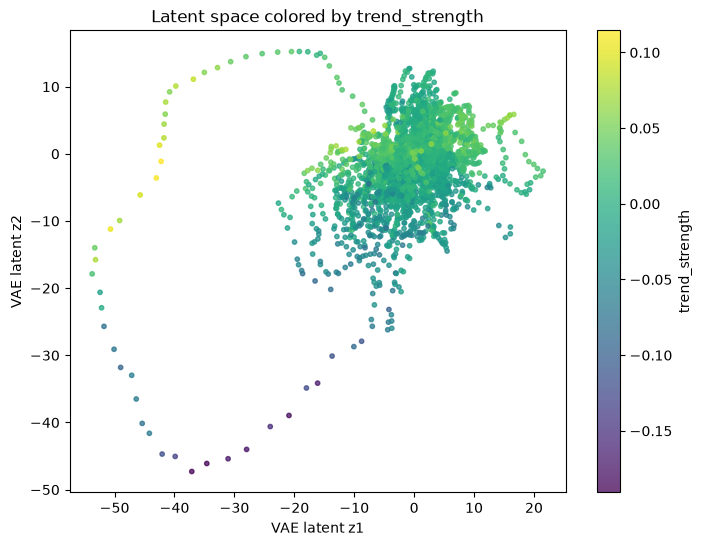

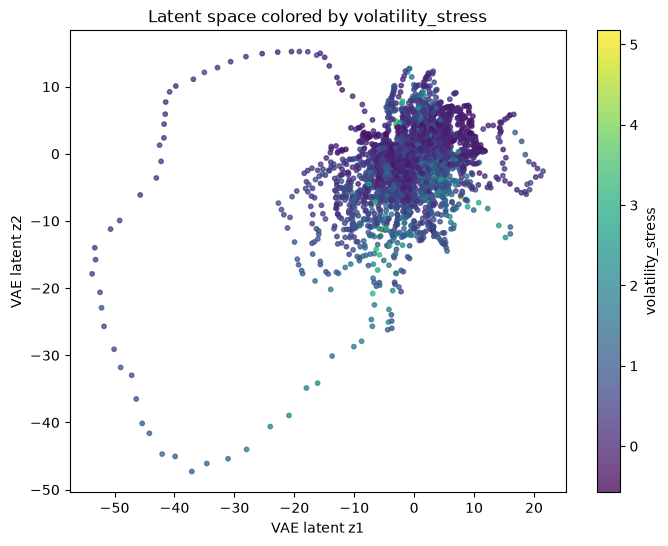

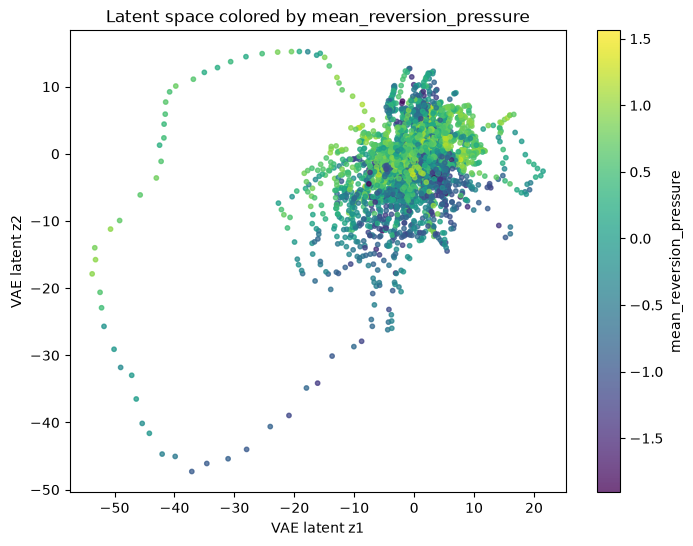

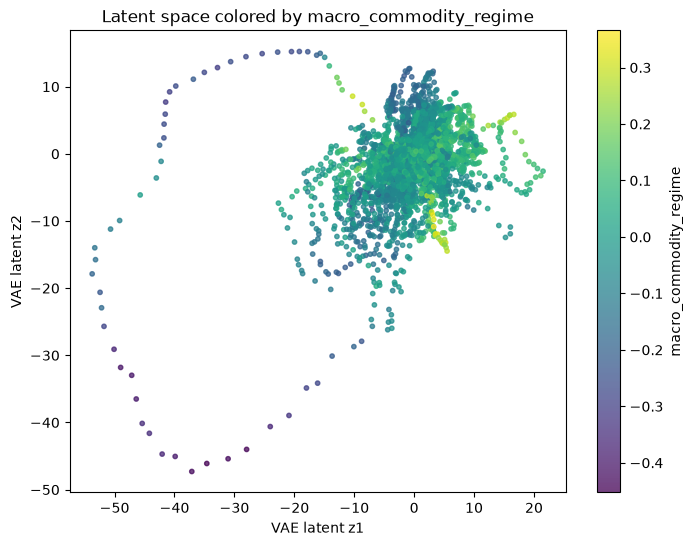

In [16]:
def scatter_latent(color_col: str, title: str | None = None):
    plt.figure(figsize=(8, 6))
    s = plt.scatter(
        analysis_df["z1"],
        analysis_df["z2"],
        c=analysis_df[color_col],
        cmap="viridis",
        s=10,
        alpha=0.75,
    )
    plt.colorbar(s, label=color_col)
    plt.xlabel("VAE latent z1")
    plt.ylabel("VAE latent z2")
    plt.title(title or f"Latent space colored by {color_col}")
    plt.show()


for col in INTERPRETATION_COLS:
    scatter_latent(col)

### How to read the latent-space color charts

Each scatter plot shows the same VAE latent space. Only the color changes.

- When colored by **trend strength**, the clearest gradient appears along `z2`. This visually supports the correlation result that `z2` is the strongest trend axis.
- When colored by **volatility stress**, high-stress points concentrate away from the stronger trend region and appear more localized.
- When colored by **mean-reversion pressure**, the pattern overlaps with trend/extension rather than forming a fully independent axis.
- When colored by **macro commodity regime**, the color gradient is more aligned with `z1`, consistent with `z1` acting as a macro-context axis.

The main takeaway is not that the latent space gives perfectly separated boxes. Instead, it organizes noisy market conditions into smooth regions that can be described economically.

## 11. Latent regimes with simple clustering

The two-dimensional latent space can also be clustered into simple regimes.

This is an interpretability step, not a trading rule. The purpose is to ask whether nearby latent points correspond to recognizable market conditions, such as:

- trend-strength regimes
- volatility-stress regimes
- commodity/macro regimes
- mixed or neutral regimes

KMeans is used only as a simple descriptive layer on top of the VAE coordinates.

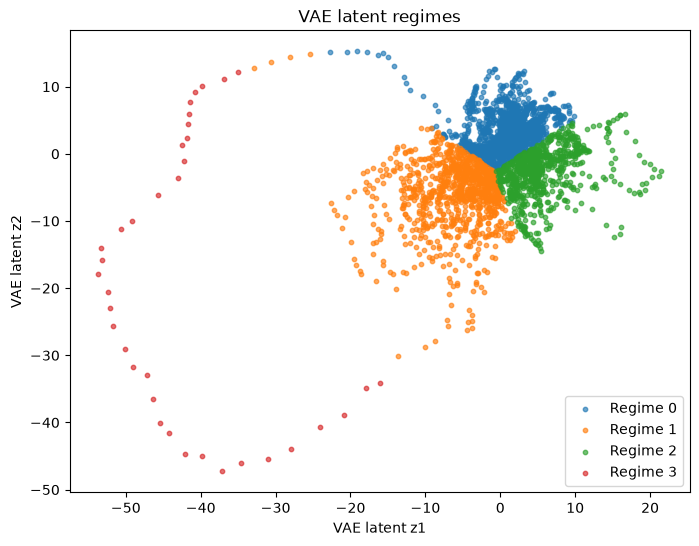

In [17]:
kmeans = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=20)
analysis_df["latent_regime"] = kmeans.fit_predict(analysis_df[["z1", "z2"]])

plt.figure(figsize=(8, 6))
for regime, sub in analysis_df.groupby("latent_regime"):
    plt.scatter(sub["z1"], sub["z2"], s=10, alpha=0.65, label=f"Regime {regime}")
plt.xlabel("VAE latent z1")
plt.ylabel("VAE latent z2")
plt.title("VAE latent regimes")
plt.legend()
plt.show()

### Result: clustered latent regimes

The clustered chart converts the continuous latent map into four discrete regions. This makes the result easier to explain, but it should be treated as descriptive.

The clusters do not prove that there are exactly four market regimes. They show that the learned latent map can be partitioned into regions with different average trend, stress, macro, and reconstruction-error characteristics.

In [18]:
regime_summary = (
    analysis_df
    .groupby("latent_regime")
    .agg(
        n_windows=("date", "count"),
        start_date=("date", "min"),
        end_date=("date", "max"),
        avg_trend_strength=("trend_strength", "mean"),
        avg_volatility_stress=("volatility_stress", "mean"),
        avg_mean_reversion_pressure=("mean_reversion_pressure", "mean"),
        avg_macro_commodity_regime=("macro_commodity_regime", "mean"),
        avg_forward_ret_5d=("forward_ret_5d", "mean"),
        avg_reconstruction_error=("reconstruction_error", "mean"),
    )
    .sort_values("n_windows", ascending=False)
)

regime_summary.round(4)

,n_windows,start_date,end_date,avg_trend_strength,avg_volatility_stress,avg_mean_reversion_pressure,avg_macro_commodity_regime,avg_forward_ret_5d,avg_reconstruction_error
latent_regime,,,,,,,,,
0,2176,2010-04-28,2026-07-10,0.0152,0.2495,0.4357,0.0009,0.0020,0.4199
1,1033,2010-05-11,2025-12-10,-0.0075,0.6052,0.0031,-0.0295,0.0042,0.7177
2,828,2010-05-04,2026-04-17,0.0018,0.5827,-0.0670,0.0457,0.0027,0.5891
3,36,2020-03-12,2020-05-01,-0.0238,0.8786,0.0658,-0.2757,0.0219,1.4311


### Result: regime summary

The regime table shows that the VAE did not merely create arbitrary clusters.

Key observations:

- The largest regime contains **2,176 windows** and combines positive trend strength with high mean-reversion pressure. This likely reflects extended but broadly constructive equity-market conditions.
- The **volatility-stress regime** is very small, with only **36 windows**, but it has the highest average volatility stress and the highest reconstruction error.
- The volatility-stress regime runs from **2020-03-12 to 2020-05-01**, matching the COVID crash/rebound period.
- The stress regime has a high average five-day forward return, but this should not be read as a trading signal. It likely reflects the violent rebound dynamics after the initial shock.

This is a useful representation-learning result: the model isolated an extreme market episode without being explicitly given an event label.

In [19]:
def name_regime(row):
    labels = []
    if row["avg_volatility_stress"] == regime_summary["avg_volatility_stress"].max():
        labels.append("volatility-stress")
    if row["avg_trend_strength"] == regime_summary["avg_trend_strength"].max():
        labels.append("trend-strength")
    if abs(row["avg_mean_reversion_pressure"]) == regime_summary["avg_mean_reversion_pressure"].abs().max():
        labels.append("mean-reversion-pressure")
    if row["avg_macro_commodity_regime"] == regime_summary["avg_macro_commodity_regime"].max():
        labels.append("commodity-macro")
    return ", ".join(labels) if labels else "mixed / neutral"

article_regimes = regime_summary.copy()
article_regimes["plain_english_label"] = article_regimes.apply(name_regime, axis=1)
article_regimes[["plain_english_label", "n_windows", "avg_forward_ret_5d", "avg_reconstruction_error"]].round(4)

,plain_english_label,n_windows,avg_forward_ret_5d,avg_reconstruction_error
latent_regime,,,,
0,"trend-strength, mean-reversion-pressure",2176,0.0020,0.4199
1,mixed / neutral,1033,0.0042,0.7177
2,commodity-macro,828,0.0027,0.5891
3,volatility-stress,36,0.0219,1.4311


### Article-friendly regime labels

The labels are generated from regime averages, not from external event knowledge.

The most interpretable labels in this run are:

- **trend-strength, mean-reversion-pressure**: the common regime, where markets are rising but also somewhat stretched.
- **commodity-macro**: a regime where the macro commodity score is relatively higher.
- **volatility-stress**: a rare regime with the highest reconstruction error and concentrated around the 2020 stress window.
- **mixed / neutral**: a broad residual regime without one dominant characteristic.

These labels should be presented as explanatory summaries, not as ground-truth market classifications.

## 12. Reconstruction error as an anomaly signal

A high reconstruction error means:

> This market window was difficult for the VAE to reconstruct from its learned latent representation.

In finance, this can be interpreted cautiously as an unusual or less familiar market state. It does **not** mean the market will go up or down. It simply means the current pattern is farther from what the compressed representation reconstructs well.

For decision-support applications, reconstruction error is most useful as a confidence signal:

```text
High reconstruction error → unusual state → reduce confidence, review manually, or avoid forcing a directional view
```

In [20]:
top_anomalies = (
    analysis_df
    .sort_values("reconstruction_error", ascending=False)
    [["date", "reconstruction_error", "trend_strength", "volatility_stress", "mean_reversion_pressure", "macro_commodity_regime", "forward_ret_5d"]]
    .head(15)
)

top_anomalies.round(4)

,date,reconstruction_error,trend_strength,volatility_stress,mean_reversion_pressure,macro_commodity_regime,forward_ret_5d
3768,2025-04-21,2.4579,-0.0516,1.0074,-0.5764,-0.0048,0.0719
3769,2025-04-22,2.3805,-0.0402,0.7846,-0.2526,-0.0097,0.0513
4013,2026-04-13,2.3427,0.0274,0.2601,0.9723,0.0584,0.0330
4012,2026-04-10,2.3392,0.0185,0.0280,0.8695,0.0296,0.0452
4014,2026-04-14,2.3382,0.0327,0.0772,1.0763,0.0625,0.0139
3770,2025-04-23,2.2906,-0.0304,0.7151,-0.0277,-0.0321,0.0357
3771,2025-04-24,2.2805,-0.0119,0.6361,0.2832,-0.0195,0.0215
4011,2026-04-09,2.2678,0.0132,0.2123,0.9902,0.1004,0.0320
4010,2026-04-08,2.2473,0.0081,0.2771,0.8702,0.1029,0.0354
3772,2025-04-25,2.1950,-0.0051,0.4340,0.4242,-0.0222,0.0293


### Result: top anomaly windows

The highest reconstruction-error dates cluster around a few periods, especially:

- **April 2025**
- **April 2026**
- **September 2015**

These dates are not automatically bullish or bearish. They are dates whose recent 20-day feature windows were relatively difficult for the VAE to reconstruct.

The most practical interpretation is:

```text
High reconstruction error = unusual market state = lower confidence in simple regime labels
```

Before connecting these dates to real-world narratives, the dates should be cross-checked against news, macro releases, volatility shocks, or data-quality effects.

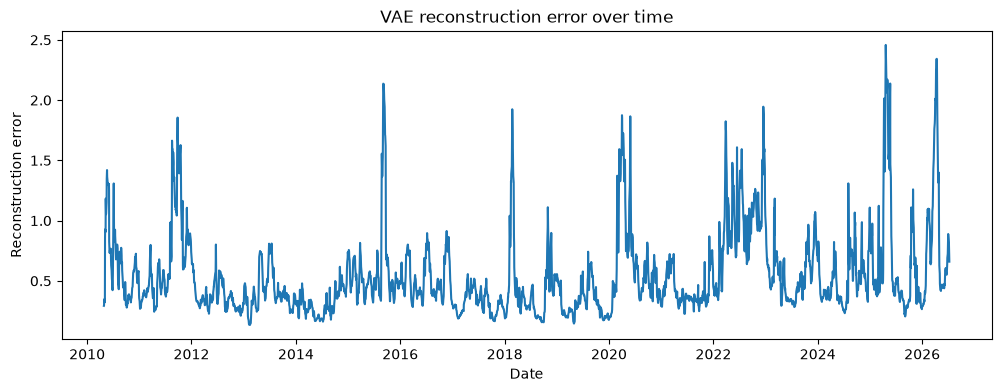

In [21]:
plt.figure(figsize=(12, 4))
plt.plot(analysis_df["date"], analysis_df["reconstruction_error"])
plt.title("VAE reconstruction error over time")
plt.xlabel("Date")
plt.ylabel("Reconstruction error")
plt.show()

### What the reconstruction-error chart shows

The reconstruction-error chart is useful as an anomaly monitor.

Periods with spikes indicate market windows that do not fit the model's compressed representation well. These windows may correspond to stress, abrupt regime transitions, unusual macro moves, or noisy input behaviour.

For decision support, reconstruction error is best used as a **caution flag**, not as a directional signal.

## 13. Simple market-state interpretation

The latent representation can be translated into simple market-state labels for communication.

This is not a trading system. It is a diagnostic layer that helps describe whether the market looks trend-like, stretched, stressed, macro-driven, or neutral.

The simple labeling logic is:

- High trend strength + low volatility stress → trend-strength conditions
- High mean-reversion pressure + moderate volatility → mean-reversion pressure
- High volatility stress or high reconstruction error → abstain / stress conditions
- High commodity-regime score → commodity-led macro context

These labels are intentionally simple. They are useful for article explanation, but a production model would need out-of-sample validation, costs, benchmarks, and sensitivity tests.

In [22]:
def simple_state_label(row):
    vol_q = analysis_df["volatility_stress"].quantile(0.75)
    recon_q = analysis_df["reconstruction_error"].quantile(0.90)
    trend_q = analysis_df["trend_strength"].quantile(0.75)
    mr_q = analysis_df["mean_reversion_pressure"].abs().quantile(0.75)
    commodity_q = analysis_df["macro_commodity_regime"].quantile(0.75)

    if row["reconstruction_error"] >= recon_q or row["volatility_stress"] >= vol_q:
        return "ABSTAIN / STRESS"
    if abs(row["mean_reversion_pressure"]) >= mr_q:
        return "MEAN_REVERSION_PRESSURE"
    if row["trend_strength"] >= trend_q:
        return "TREND_STRENGTH"
    if row["macro_commodity_regime"] >= commodity_q:
        return "COMMODITY_MACRO"
    return "MIXED / NEUTRAL"

analysis_df["simple_state_label"] = analysis_df.apply(simple_state_label, axis=1)

state_summary = (
    analysis_df
    .groupby("simple_state_label")
    .agg(
        n_windows=("date", "count"),
        avg_forward_ret_5d=("forward_ret_5d", "mean"),
        avg_trend_strength=("trend_strength", "mean"),
        avg_volatility_stress=("volatility_stress", "mean"),
        avg_mean_reversion_pressure=("mean_reversion_pressure", "mean"),
        avg_macro_commodity_regime=("macro_commodity_regime", "mean"),
        avg_reconstruction_error=("reconstruction_error", "mean"),
    )
    .sort_values("n_windows", ascending=False)
)

state_summary.round(4)

,n_windows,avg_forward_ret_5d,avg_trend_strength,avg_volatility_stress,avg_mean_reversion_pressure,avg_macro_commodity_regime,avg_reconstruction_error
simple_state_label,,,,,,,
MIXED / NEUTRAL,1317,0.0026,0.0054,0.2295,0.2747,-0.0261,0.4407
ABSTAIN / STRESS,1253,0.0038,-0.0100,1.0026,-0.3354,-0.0195,0.7708
MEAN_REVERSION_PRESSURE,612,0.0021,0.0199,0.0488,0.8456,0.0212,0.4013
TREND_STRENGTH,562,0.0037,0.0296,0.0321,0.6148,0.0311,0.4730
COMMODITY_MACRO,329,0.0001,0.0073,0.2300,0.2847,0.0838,0.4158


### Result: simple market-state labels

The simple label summary is consistent with the earlier analysis:

- `ABSTAIN / STRESS` has the highest average volatility stress and the highest reconstruction error.
- `TREND_STRENGTH` has the highest average trend strength.
- `MEAN_REVERSION_PRESSURE` has the highest mean-reversion pressure.
- `COMMODITY_MACRO` has the highest macro commodity regime score, but its average forward return is close to zero in this run.

The forward-return differences are modest and should not be overstated. The labels are more useful for describing state conditions than for claiming a tradable edge.

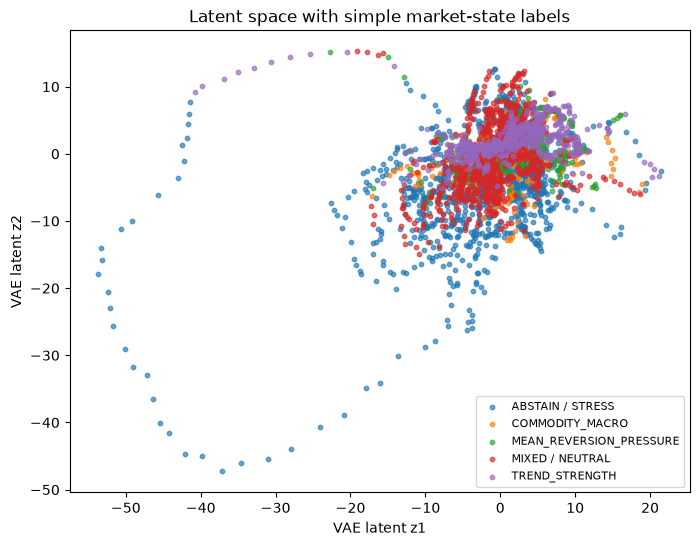

In [23]:
plt.figure(figsize=(8, 6))
for label, sub in analysis_df.groupby("simple_state_label"):
    plt.scatter(sub["z1"], sub["z2"], s=10, alpha=0.65, label=label)
plt.xlabel("VAE latent z1")
plt.ylabel("VAE latent z2")
plt.title("Latent space with simple market-state labels")
plt.legend(fontsize=8)
plt.show()

### What the labeled latent-space chart shows

The labeled chart translates the continuous VAE map into human-readable states.

The key point is that `ABSTAIN / STRESS` occupies a distinct portion of the latent map, while trend and mean-reversion states overlap more. That overlap is realistic: stretched markets often occur during strong trends, so trend-following and mean-reversion pressure are not always cleanly separable.

This supports a cautious decision-support interpretation: the VAE is better at organizing states and identifying unusual zones than at producing a standalone trading rule.

## 14. Standalone interpretation summary

The next cell generates a short interpretation from the executed results. It is useful as an article summary, but the detailed discussion below the charts is the more reliable way to read the notebook.

In [24]:
def make_interpretation_summary(corr_table: pd.DataFrame, regime_summary: pd.DataFrame, state_summary: pd.DataFrame) -> str:
    strongest = []
    for z in ["z1", "z2"]:
        vals = corr_table.loc[z].dropna().abs().sort_values(ascending=False)
        if len(vals):
            strongest.append((z, vals.index[0], corr_table.loc[z, vals.index[0]]))

    lines = []
    lines.append("# Interpretation")
    lines.append("")
    lines.append("The VAE compresses rolling S&P 500 market windows into a two-dimensional latent space.")
    lines.append("Instead of treating the latent variables as direct forecasts, the latent coordinates are interpreted as market-state representations.")
    lines.append("")

    for z, concept, corr in strongest:
        lines.append(f"- `{z}` is most associated with `{concept}` in this run, with correlation {corr:.3f}.")

    lines.append("")
    lines.append("The latent clusters indicate whether the model separates trend, stress, mean-reversion pressure, and commodity/macro context.")
    lines.append("High reconstruction-error windows can be treated as unusual regimes where a decision-support process may reduce confidence, flag the date for review, or avoid forcing a directional interpretation.")
    lines.append("")
    lines.append("The key message is not that the VAE predicts returns by itself. The value is that a probabilistic latent representation can summarize recent market behaviour and support regime interpretation, anomaly detection, and further statistical testing.")

    return "\n".join(lines)


print(make_interpretation_summary(correlation_table, regime_summary, state_summary))


# Interpretation

The VAE compresses rolling S&P 500 market windows into a two-dimensional latent space.
Instead of treating the latent variables as direct forecasts, the latent coordinates are interpreted as market-state representations.

- `z1` is most associated with `macro_commodity_regime` in this run, with correlation 0.458.
- `z2` is most associated with `trend_strength` in this run, with correlation 0.662.

The latent clusters indicate whether the model separates trend, stress, mean-reversion pressure, and commodity/macro context.
High reconstruction-error windows can be treated as unusual regimes where a decision-support process may reduce confidence, flag the date for review, or avoid forcing a directional interpretation.

The key message is not that the VAE predicts returns by itself. The value is that a probabilistic latent representation can summarize recent market behaviour and support regime interpretation, anomaly detection, and further statistical testing.


### Final interpretation of the run

The strongest result is that the VAE latent space is economically interpretable:

- `z2` behaves primarily like a trend-strength axis.
- `z1` behaves primarily like a macro-commodity context axis.
- reconstruction error works as a useful anomaly or uncertainty score.

The weakest part of the result is direct return prediction. The forward-return statistics are descriptive and should not be used as evidence of a trading edge without a full out-of-sample test and transaction-cost-aware benchmark.

## 15. Conclusion and limitations

The VAE provides a compact representation of rolling S&P 500 market windows. In this run, the latent space is interpretable when compared with trend, volatility, mean-reversion, and macro-context features.

The strongest use of the model is **representation learning**, not direct price prediction:

```text
Rolling market window
    ↓
Trend / volatility / mean-reversion / macro features
    ↓
VAE latent representation
    ↓
Market-state interpretation
    ↓
Decision support, anomaly detection, or further statistical testing
```

### Main findings from this run

- `z2` is most strongly associated with **trend strength**.
- `z1` is most strongly associated with **macro commodity context**.
- Volatility stress appears partly through the negative side of the trend axis and partly through higher reconstruction error.
- Mean-reversion pressure is present, but it is mixed with trend/extension rather than cleanly isolated in its own latent dimension.
- The small volatility-stress cluster is concentrated around the COVID crash/rebound window and has the highest reconstruction error.
- High reconstruction-error windows identify unusual market states, but they should not be interpreted as automatic buy or sell signals.

### Important limitations

- The latent dimensions are learned, not predefined.
- Correlations help interpretation, but they are not causal evidence.
- Regime labels are exploratory and should be tested out of sample.
- Forward returns are raw diagnostics and are not adjusted for risk, market drift, transaction costs, or benchmark exposure.
- The model uses a low-dimensional latent space for readability. A higher-dimensional latent space may separate trend, volatility, macro context, and mean reversion more cleanly.
- Reconstruction error is an anomaly signal, not a standalone trading rule.

A cautious conclusion is:

> A simple VAE can organize rolling S&P 500 market windows into an interpretable latent space. In this experiment, one latent direction is most closely associated with trend strength, another with macro-commodity context, while reconstruction error highlights unusual market states.

## Research and investment disclaimer

This notebook is for educational and research purposes only. It is not investment advice, a trading recommendation, or a complete risk-management system.

The analysis is exploratory. It uses public market data, engineered features, and unsupervised representation learning to study market states. The results should not be used to make trading decisions without additional validation, including out-of-sample testing, transaction costs, liquidity assumptions, benchmark comparisons, sensitivity analysis, and independent review.

Financial markets involve substantial risk. Past behaviour, latent clusters, reconstruction error, or historical forward returns do not guarantee future outcomes.